In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# fresh runtime: install compatible TF & required libs (Colab-friendly)
!pip install -q rasterio joblib matplotlib tqdm scikit-learn
!pip install -q "tensorflow==2.19.0"
print("Installed packages. Now check TF & GPU in the next cell.")


Installed packages. Now check TF & GPU in the next cell.


In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted at /content/drive")
# Your uploaded file path (use this if you uploaded the zip to Drive):
DRIVE_ZIP_PATH = "/content/drive/MyDrive/EuroSAT_MS.zip"
print("Expected ZIP path in Drive:", DRIVE_ZIP_PATH)

Mounted at /content/drive
Drive mounted at /content/drive
Expected ZIP path in Drive: /content/drive/MyDrive/EuroSAT_MS.zip


In [ ]:
# Unzip the dataset from your Drive into a working folder in Colab
!mkdir -p /content/dataset
!unzip -q "/content/drive/MyDrive/EuroSAT_MS.zip" -d /content/dataset || echo "Unzip failed (check Drive path)"

# Show resulting folder structure (first levels)
!ls -la /content/dataset | sed -n '1,200p'
!ls -la /content/dataset/EuroSAT_MS | sed -n '1,200p' || true


total 12
drwxr-xr-x  3 root root 4096 Nov 26 11:28 .
drwxr-xr-x  1 root root 4096 Nov 26 11:27 ..
drwxr-xr-x 12 root root 4096 Mar  9  2023 EuroSAT_MS
total 1140
drwxr-xr-x 12 root root   4096 Mar  9  2023 .
drwxr-xr-x  3 root root   4096 Nov 26 11:28 ..
drwxr-xr-x  2 root root 135168 Sep  1  2017 AnnualCrop
drwxr-xr-x  2 root root 114688 Sep  1  2017 Forest
drwxr-xr-x  2 root root 167936 Sep  1  2017 HerbaceousVegetation
drwxr-xr-x  2 root root  73728 Sep  1  2017 Highway
drwxr-xr-x  2 root root 114688 Sep  1  2017 Industrial
drwxr-xr-x  2 root root  69632 Sep  1  2017 Pasture
drwxr-xr-x  2 root root 122880 Sep  1  2017 PermanentCrop
drwxr-xr-x  2 root root 126976 Sep  1  2017 Residential
drwxr-xr-x  2 root root  77824 Sep  1  2017 River
drwxr-xr-x  2 root root 114688 Sep  1  2017 SeaLake


In [ ]:
import os, glob
# Most likely dataset root after unzip:
DATA_ROOT = "/content/dataset/EuroSAT_MS"

if not os.path.exists(DATA_ROOT):
    print("Dataset not found at", DATA_ROOT)
    print("Listing /content/dataset:")
    print(os.listdir("/content/dataset"))
else:
    classes = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])
    print("Dataset root OK. Classes found:", classes)
    # show a small sample
    for cls in classes[:5]:
        files = glob.glob(os.path.join(DATA_ROOT, cls, "*.tif"))
        print(f"  {cls}: {len(files)} images. Example:", files[:3])

Dataset root OK. Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  AnnualCrop: 3000 images. Example: ['/content/dataset/EuroSAT_MS/AnnualCrop/AnnualCrop_644.tif', '/content/dataset/EuroSAT_MS/AnnualCrop/AnnualCrop_132.tif', '/content/dataset/EuroSAT_MS/AnnualCrop/AnnualCrop_2382.tif']
  Forest: 3000 images. Example: ['/content/dataset/EuroSAT_MS/Forest/Forest_588.tif', '/content/dataset/EuroSAT_MS/Forest/Forest_1754.tif', '/content/dataset/EuroSAT_MS/Forest/Forest_431.tif']
  HerbaceousVegetation: 3000 images. Example: ['/content/dataset/EuroSAT_MS/HerbaceousVegetation/HerbaceousVegetation_2827.tif', '/content/dataset/EuroSAT_MS/HerbaceousVegetation/HerbaceousVegetation_2895.tif', '/content/dataset/EuroSAT_MS/HerbaceousVegetation/HerbaceousVegetation_2639.tif']
  Highway: 2500 images. Example: ['/content/dataset/EuroSAT_MS/Highway/Highway_1610.tif', '/content/dataset/EuroSAT_MS/Highw

In [ ]:
%%bash
cat > train_eurosat.py << 'PY'
# train_eurosat.py  (Colab-ready)
import os, glob, random
import numpy as np
import rasterio
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# -------- USER SETTINGS ----------
DATA_ROOT = "/content/dataset/EuroSAT_MS"   # Colab path - adjust if needed
IMG_SHAPE = (64,64,13)
BATCH_SIZE = 16   # change if OOM
EPOCHS = 15       # change if you want more/less
PATIENCE = 4
OUT_MODEL = "/content/drive/MyDrive/eurosat_13band_best.h5"
LABEL_INFO = "/content/drive/MyDrive/eurosat_label_info.joblib"
SEED = 42
# ---------------------------------

tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# 1) discover files and labels
class_dirs = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])
if not class_dirs:
    raise RuntimeError(f"No class subfolders found under {DATA_ROOT}. Check dataset path.")
filepaths=[]; labels=[]
for cls in class_dirs:
    cls_dir = os.path.join(DATA_ROOT, cls)
    files = glob.glob(os.path.join(cls_dir, "*.tif")) + glob.glob(os.path.join(cls_dir, "*.tiff"))
    for f in files:
        filepaths.append(f); labels.append(cls)

filepaths = np.array(filepaths)
labels = np.array(labels)
print("Total samples:", len(filepaths))

# 2) encode labels
le = LabelEncoder()
labels_enc = le.fit_transform(labels)
class_names = list(le.classes_)
num_classes = len(class_names)
print("Classes:", class_names)

# 3) train/val/test split (stratified)
train_val_files, test_files, train_val_labels, test_labels = train_test_split(
    filepaths, labels_enc, test_size=0.10, stratify=labels_enc, random_state=SEED)

train_files, val_files, train_labels, val_labels = train_test_split(
    train_val_files, train_val_labels, test_size=0.15, stratify=train_val_labels, random_state=SEED)

print(f"Split -> Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

# 4) loader: read tif into (64,64,13) float32 array normalized roughly to [0,1]
def load_tif_as_array(path):
    with rasterio.open(path, 'r') as src:
        arr = src.read().astype('float32')   # shape (bands, H, W)
    arr = np.transpose(arr, (1,2,0))         # (H, W, bands)
    # many Sentinel-derived datasets are scaled by 10000
    if np.nanmax(arr) > 2.0:
        arr = arr / 10000.0
    arr = np.clip(arr, -1.0, 1.0)
    return arr.astype('float32')

# wrapper for tf.numpy_function
def tf_load_tif(path):
    def _load(path_str):
        p = path_str.decode('utf-8')
        return load_tif_as_array(p)
    arr = tf.numpy_function(_load, [path], tf.float32)
    arr.set_shape(list(IMG_SHAPE))
    return arr

def make_dataset(files, labels, batch=BATCH_SIZE, shuffle=True, augment=False):
    files_ds = tf.data.Dataset.from_tensor_slices(files)
    labels_ds = tf.data.Dataset.from_tensor_slices(labels.astype('int32'))
    ds = tf.data.Dataset.zip((files_ds, labels_ds))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(files), seed=SEED)
    def _parse(path, lab):
        img = tf_load_tif(path)
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
        return img, tf.one_hot(lab, depth=num_classes)
    ds = ds.map(_parse, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_files, train_labels, batch=BATCH_SIZE, shuffle=True, augment=True)
val_ds = make_dataset(val_files, val_labels, batch=BATCH_SIZE, shuffle=False, augment=False)
test_ds = make_dataset(test_files, test_labels, batch=BATCH_SIZE, shuffle=False, augment=False)

# 5) build model (small & efficient)
def build_model(input_shape=IMG_SHAPE, num_classes=num_classes):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32,3,activation='relu',padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D(2)(x)

    x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D(2)(x)

    x = layers.Conv2D(128,3,activation='relu',padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128,activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inp, outputs=out)

model = build_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 6) callbacks and training
cbs = [
    callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True, monitor='val_loss'),
    callbacks.ModelCheckpoint(OUT_MODEL, save_best_only=True, monitor='val_loss')
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cbs)

# save model & label info
try:
    model.save(OUT_MODEL)
    print("Saved model:", OUT_MODEL)
except Exception as e:
    print("Error saving model:", e)

joblib.dump({'label_encoder': le, 'class_names': class_names}, LABEL_INFO)
print("Saved label info:", LABEL_INFO)

# 7) evaluation helpers
def evaluate(ds, set_name="set"):
    y_true=[]; y_pred=[]
    for imgs, labs in ds:
        preds = model.predict(imgs)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labs.numpy(), axis=1))
    print(f"\nClassification report ({set_name}):")
    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    print(f"Confusion matrix ({set_name}):\n", cm)
    return cm

print("\n== Validation ==")
val_cm = evaluate(val_ds, "Validation")
print("\n== Test ==")
test_cm = evaluate(test_ds, "Test")

# 8) save plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_curves_13band.png", dpi=150)
plt.show()

# confusion matrix plot for validation
import itertools
plt.figure(figsize=(6,6)); plt.imshow(val_cm, interpolation='nearest', cmap=plt.cm.Blues); plt.title("Validation Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45); plt.yticks(ticks, class_names)
thresh = val_cm.max()/2.
for i,j in itertools.product(range(val_cm.shape[0]), range(val_cm.shape[1])):
    plt.text(j,i,format(val_cm[i,j],'d'), ha='center', color='white' if val_cm[i,j]>thresh else 'black')
plt.tight_layout(); plt.savefig("/content/drive/MyDrive/val_confusion_matrix_13band.png", dpi=150); plt.show()
PY


In [ ]:
!python -u train_eurosat.py

2025-11-26 11:29:24.935842: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764156565.201423    1244 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764156565.275072    1244 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764156565.322278    1244 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764156565.322318    1244 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764156565.322326    1244 computation_placer.cc:177] computation placer alr

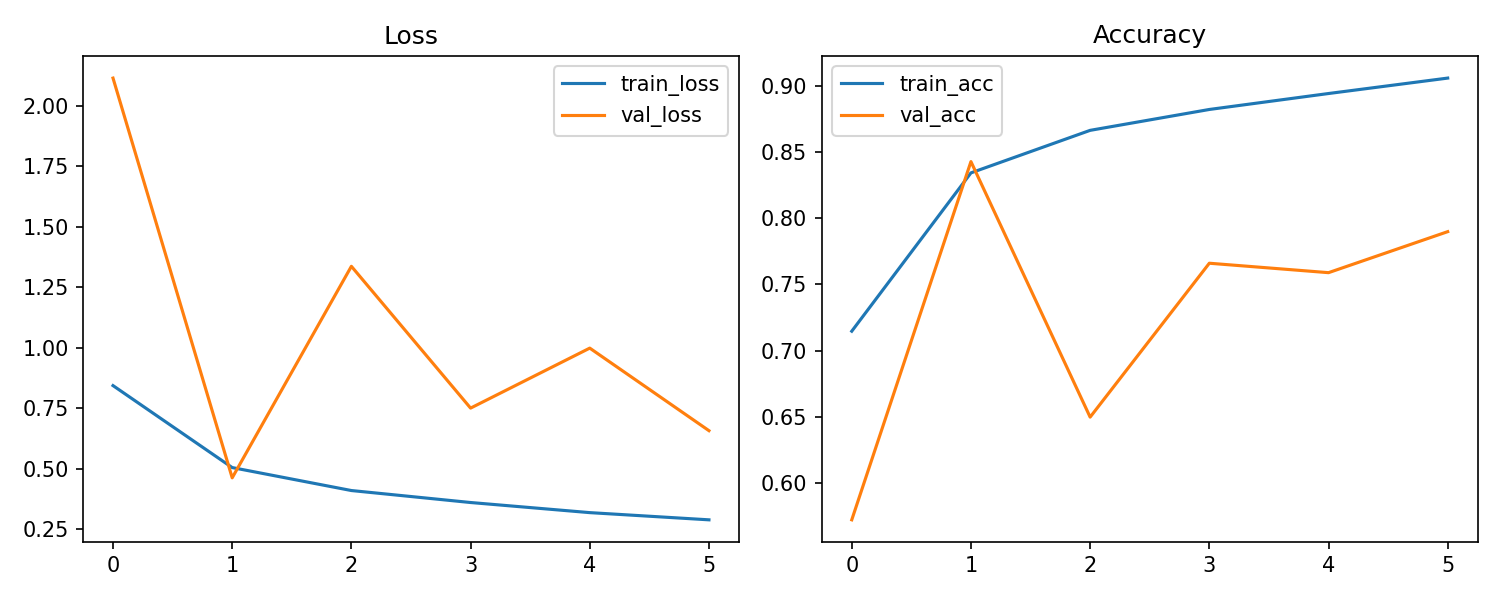

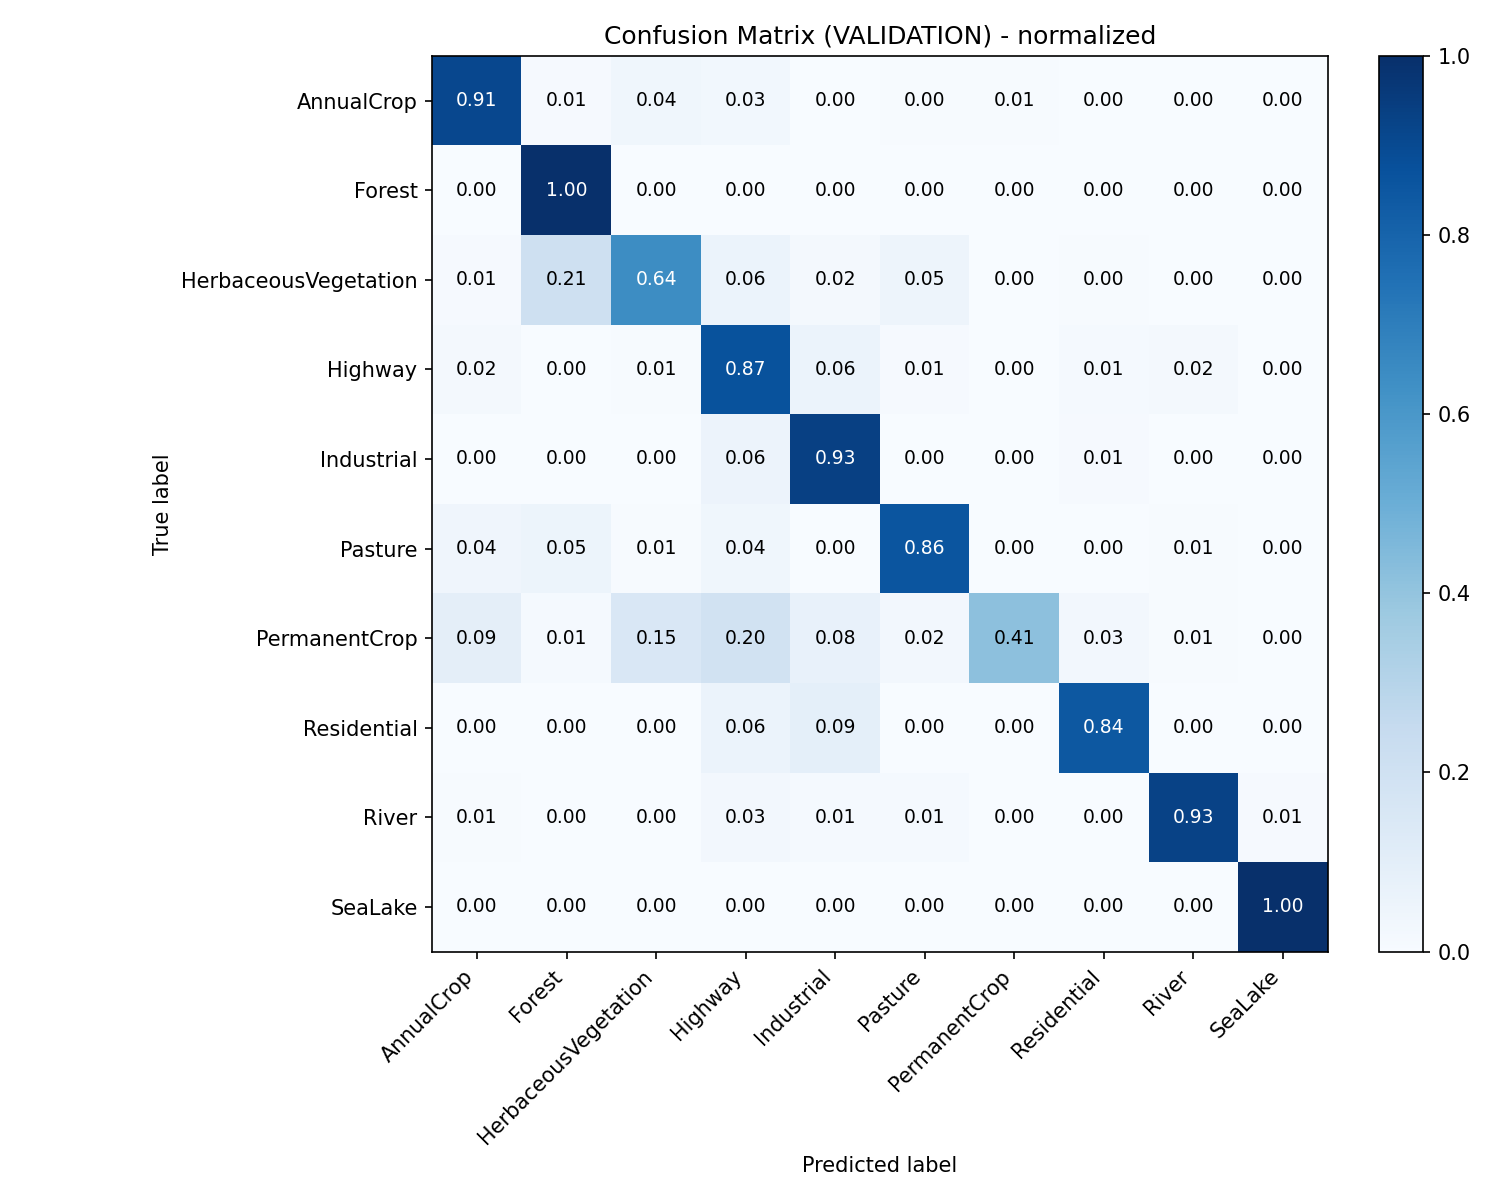

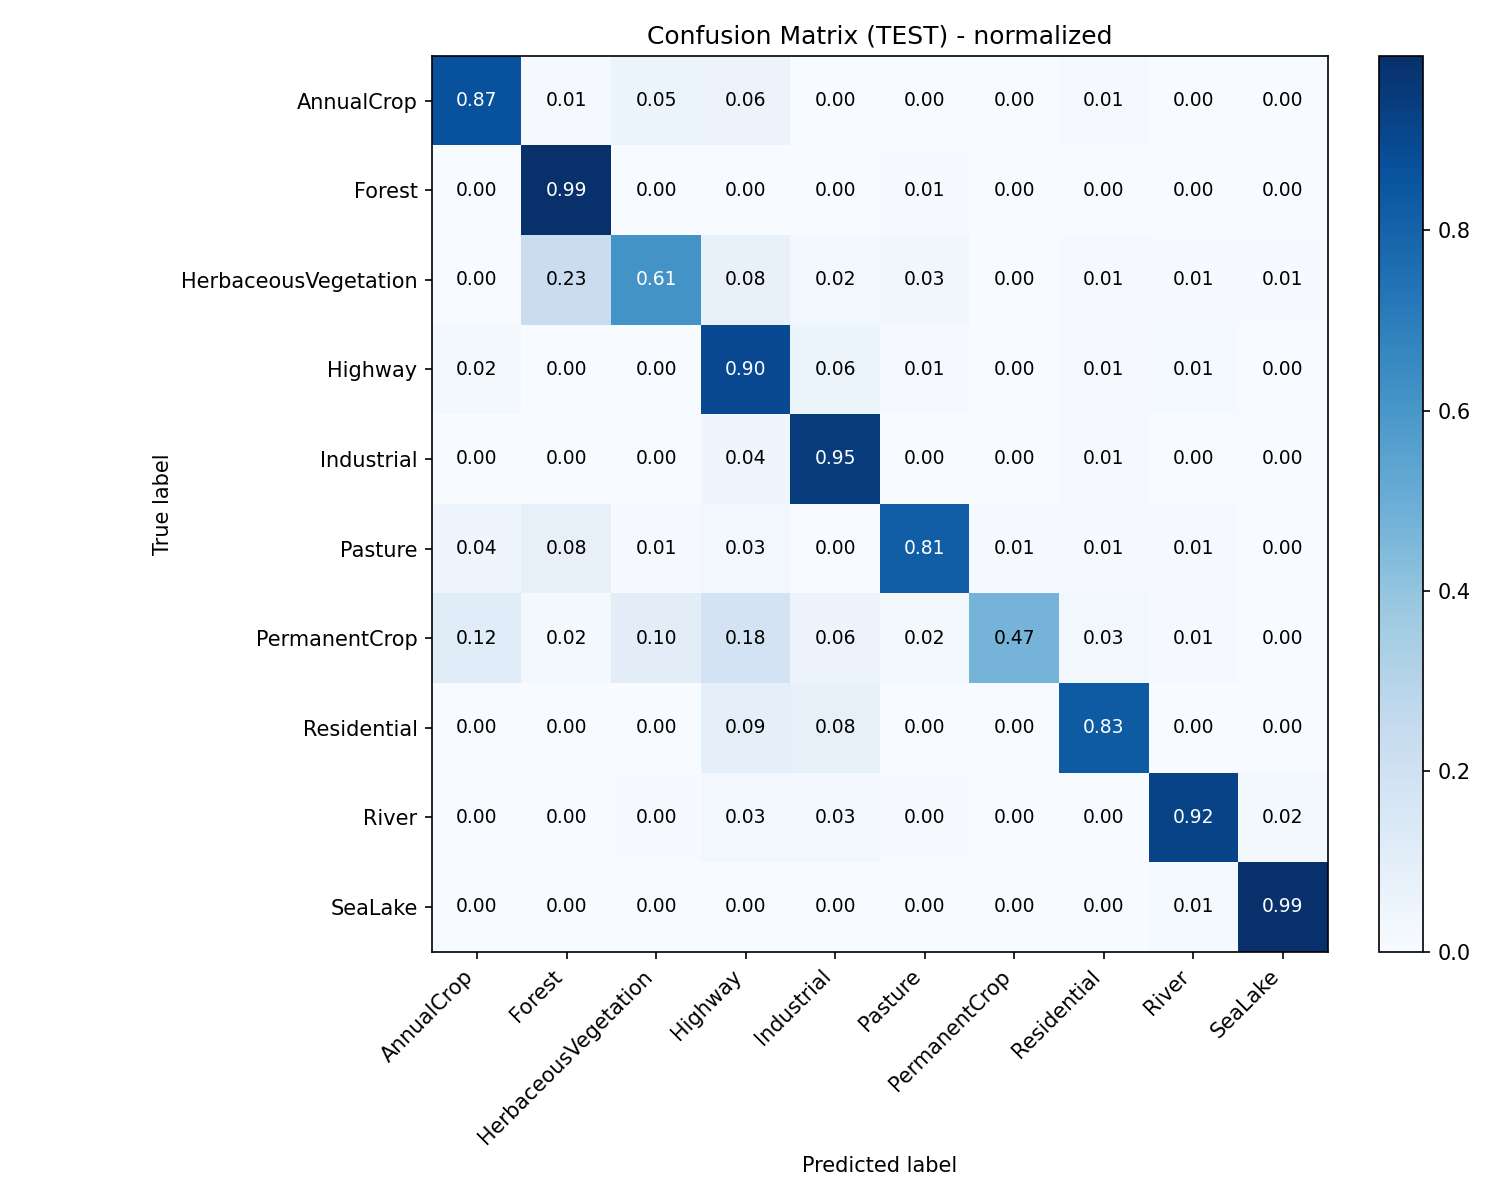

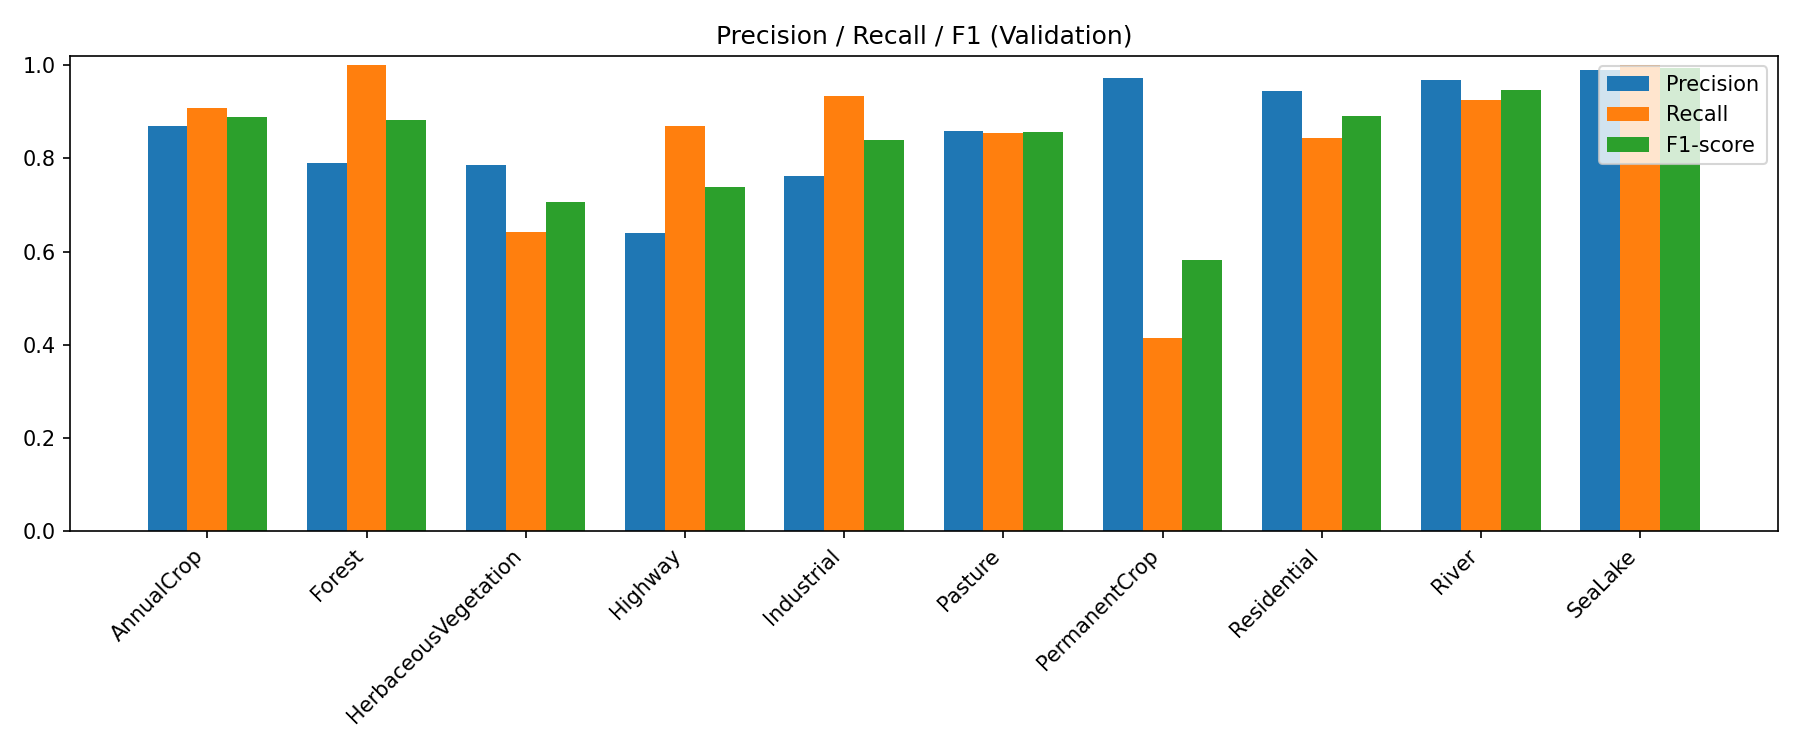

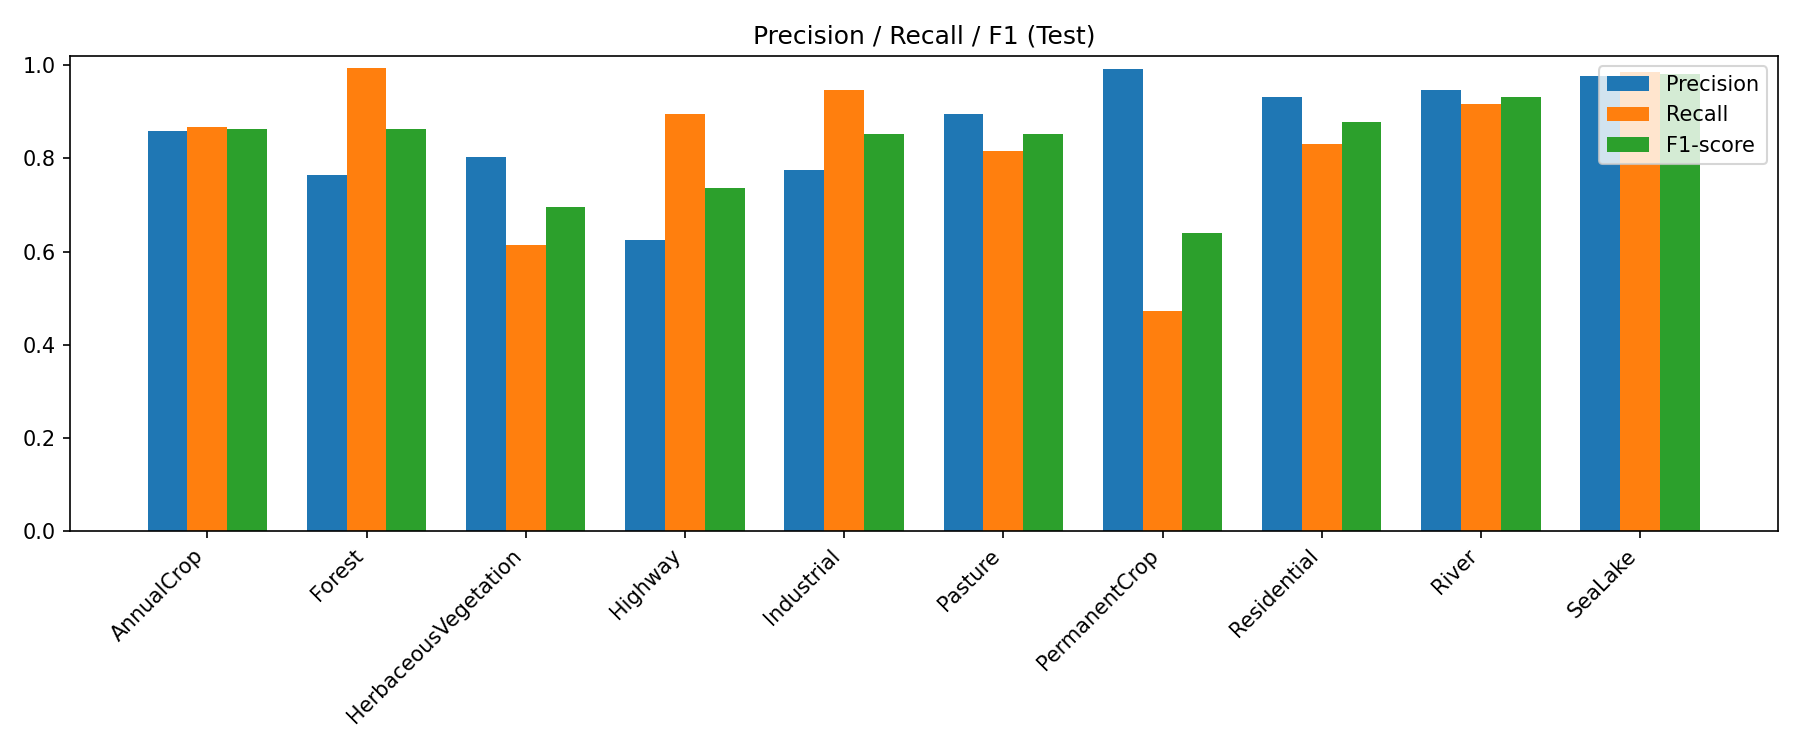

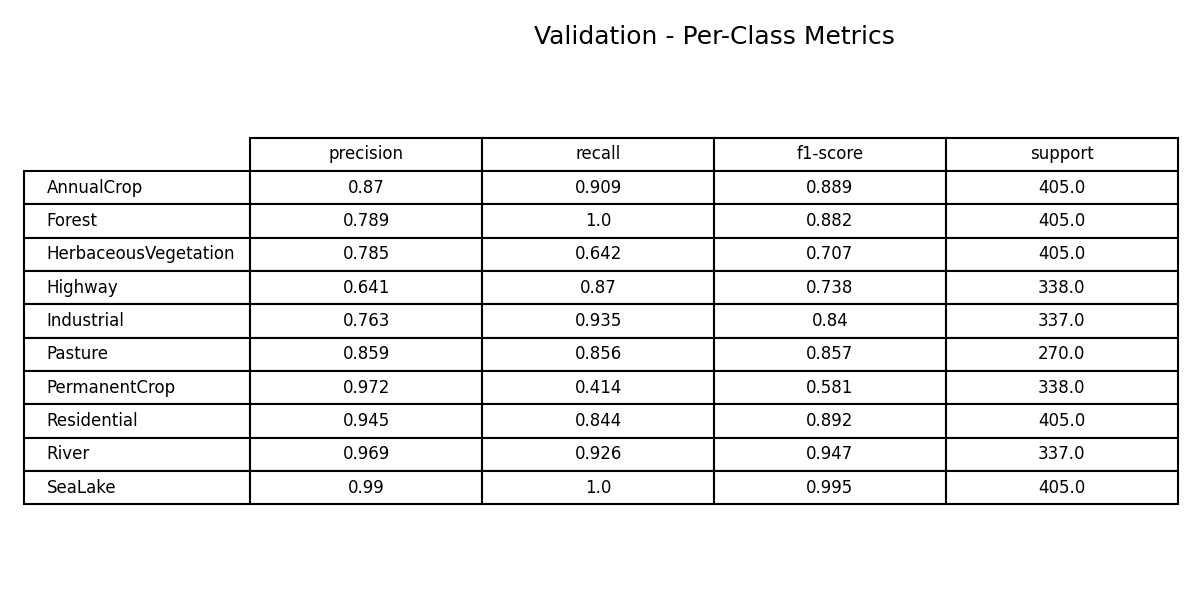

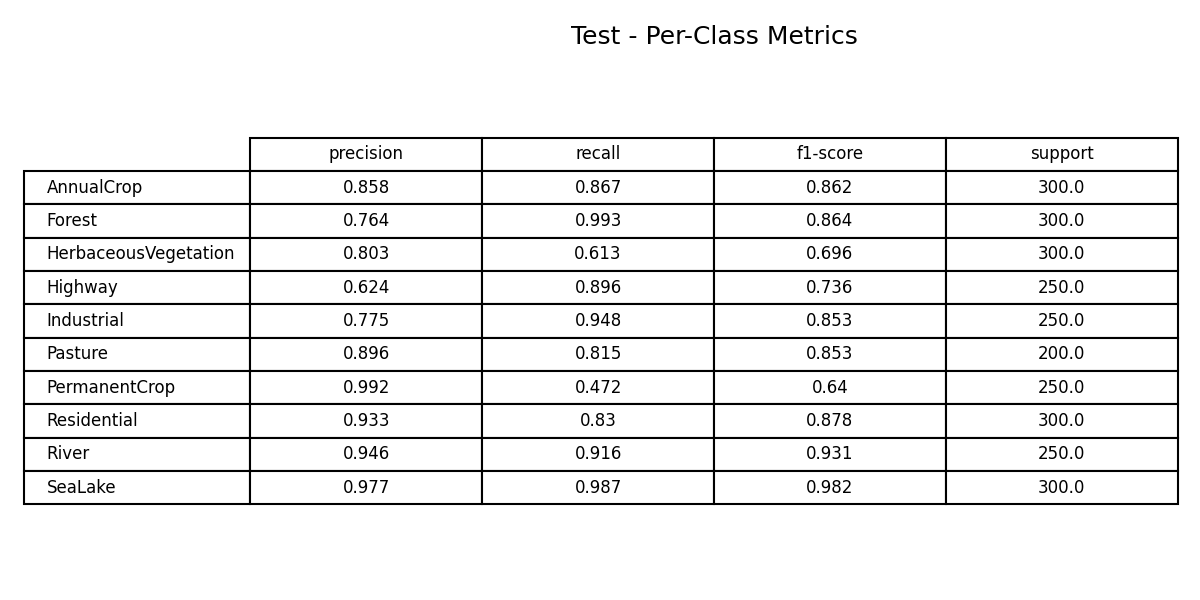

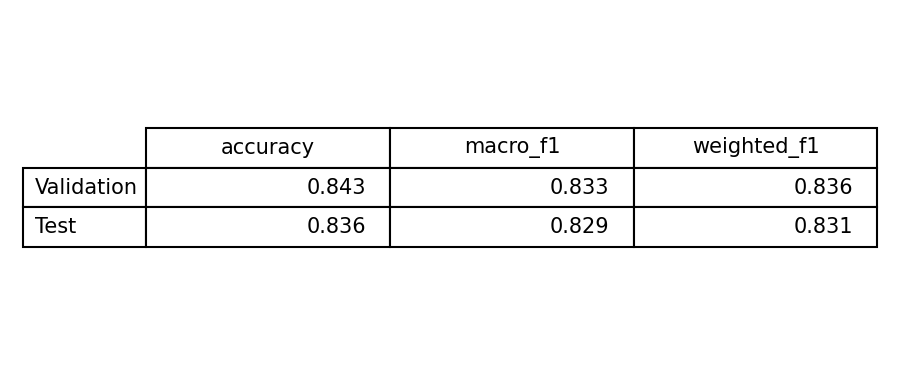

In [ ]:
# ======== Save ALL metrics + plots as IMAGES and display only images =========
import os, glob, numpy as np, rasterio, joblib, itertools, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import Image, display, clear_output
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ----------------- USER PATHS (edit if different) -----------------
DATA_ROOT   = "/content/dataset/EuroSAT_MS"   # adjust if your dataset path differs
MODEL_PATH  = "/content/drive/MyDrive/eurosat_13band_best.h5"
LABEL_INFO  = "/content/drive/MyDrive/eurosat_label_info.joblib"
OUT_DIR     = "/content/drive/MyDrive/EuroSAT_results_images"
TRAINING_IMAGE_FALLBACK = "/content/drive/MyDrive/training_curves_13band.png"
BATCH_SIZE  = 32
IMG_SHAPE   = (64,64,13)
# ------------------------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)

# --- Load label info ---
info = joblib.load(LABEL_INFO)
if 'class_names' in info:
    class_names = info['class_names']
else:
    # fallback: label_encoder stored
    class_names = list(info['label_encoder'].classes_)
num_classes = len(class_names)

# --- Rebuild deterministic splits (same logic as training) ---
SEED = 42
all_files = []
all_labels = []
for cls in sorted(os.listdir(DATA_ROOT)):
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        continue
    files = glob.glob(os.path.join(cls_dir, "*.tif")) + glob.glob(os.path.join(cls_dir, "*.tiff"))
    all_files += files
    all_labels += [cls] * len(files)
all_files = np.array(all_files)
all_labels = np.array(all_labels)

le2 = LabelEncoder()
labels_enc = le2.fit_transform(all_labels)
# map to saved ordering to ensure consistent indices
if set(class_names) == set(le2.classes_):
    mapping = {c: i for i, c in enumerate(class_names)}
    labels_enc = np.array([mapping[c] for c in all_labels])
else:
    # names don't match exactly — warn silently (we won't print) and use le2 ordering
    class_names = list(le2.classes_)

train_val_files, test_files, train_val_labels, test_labels = train_test_split(
    all_files, labels_enc, test_size=0.10, stratify=labels_enc, random_state=SEED)
train_files, val_files, train_labels, val_labels = train_test_split(
    train_val_files, train_val_labels, test_size=0.15, stratify=train_val_labels, random_state=SEED)

# --- Loader for prediction (same preprocessing used in training) ---
def load_tif_as_array(path):
    with rasterio.open(path, 'r') as src:
        arr = src.read().astype('float32')   # (bands, H, W)
    arr = np.transpose(arr, (1,2,0))        # (H, W, bands)
    if np.nanmax(arr) > 2.0:
        arr = arr / 10000.0
    arr = np.clip(arr, -1.0, 1.0)
    return arr.astype('float32')

def make_ds(files, labels, batch=BATCH_SIZE):
    files_ds = tf.data.Dataset.from_tensor_slices(files)
    labels_ds = tf.data.Dataset.from_tensor_slices(labels.astype('int32'))
    ds = tf.data.Dataset.zip((files_ds, labels_ds))
    def _parse(path, lab):
        def _load(p):
            p = p.decode('utf-8')
            return load_tif_as_array(p)
        img = tf.numpy_function(_load, [path], tf.float32)
        img.set_shape(list(IMG_SHAPE))
        return img, lab
    ds = ds.map(_parse, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

val_ds = make_ds(val_files, val_labels, batch=BATCH_SIZE)
test_ds = make_ds(test_files, test_labels, batch=BATCH_SIZE)

# --- Load model (inference only) ---
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# --- Predict helper ---
def predict_ds(ds):
    y_true = []
    y_pred = []
    for imgs, labs in ds:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labs.numpy().astype(int))
    return np.array(y_true), np.array(y_pred)

y_val_true, y_val_pred = predict_ds(val_ds)
y_test_true, y_test_pred = predict_ds(test_ds)

# --- Compute classification reports and dataframes ---
rep_val = classification_report(y_val_true, y_val_pred, target_names=class_names, output_dict=True)
rep_test = classification_report(y_test_true, y_test_pred, target_names=class_names, output_dict=True)
df_val = pd.DataFrame(rep_val).transpose()
df_test = pd.DataFrame(rep_test).transpose()

# ----------------- Plotting & saving helpers -----------------
def save_loss_acc_images(out_dir):
    # Look for in-memory history object created by training run (common variable name 'history')
    hist = None
    if 'history' in globals() and hasattr(history, 'history'):
        hist = history.history
    # check alternate names
    for alt in ['history_1', 'hist', 'histories', 'h']:
        if hist is None and alt in globals() and hasattr(globals()[alt], 'history'):
            hist = globals()[alt].history

    loss_png = os.path.join(out_dir, "loss_curve.png")
    acc_png  = os.path.join(out_dir, "accuracy_curve.png")

    if hist is None:
        # fallback: copy training image if present (so notebook still shows something)
        if os.path.exists(TRAINING_IMAGE_FALLBACK):
            from shutil import copyfile
            copyfile(TRAINING_IMAGE_FALLBACK, os.path.join(out_dir, "training_curves_fallback.png"))
        return loss_png, acc_png

    train_loss = hist.get('loss', [])
    val_loss   = hist.get('val_loss', [])
    train_acc  = hist.get('accuracy', hist.get('acc', []))
    val_acc    = hist.get('val_accuracy', hist.get('val_acc', []))
    epochs = np.arange(1, max(len(train_loss), len(val_loss), len(train_acc), len(val_acc)) + 1)

    # Loss plot
    plt.figure(figsize=(8,5))
    if len(train_loss): plt.plot(epochs[:len(train_loss)], train_loss, marker='o', linewidth=2, label='Training Loss')
    if len(val_loss):   plt.plot(epochs[:len(val_loss)],   val_loss,   marker='s', linewidth=2, label='Validation Loss')
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.xticks(epochs)
    plt.grid(alpha=0.25); plt.legend(); plt.tight_layout()
    plt.savefig(loss_png, dpi=150); plt.close()

    # Accuracy plot
    plt.figure(figsize=(8,5))
    if len(train_acc): plt.plot(epochs[:len(train_acc)], train_acc, marker='o', linewidth=2, label='Training Accuracy')
    if len(val_acc):   plt.plot(epochs[:len(val_acc)],   val_acc,   marker='s', linewidth=2, label='Validation Accuracy')
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.xticks(epochs); plt.ylim(0,1)
    plt.grid(alpha=0.25); plt.legend(); plt.tight_layout()
    plt.savefig(acc_png, dpi=150); plt.close()

    return loss_png, acc_png

def plot_confusion(cm, classes, outpath, normalize=True, setname=""):
    cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] if normalize else cm
    fig, ax = plt.subplots(figsize=(10,8))
    im = ax.imshow(cmn, interpolation='nearest', cmap=plt.cm.Blues)
    title = f"Confusion Matrix ({setname.upper()}) - normalized" if normalize else f"Confusion Matrix ({setname.upper()})"
    ax.set_title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ticks = np.arange(len(classes))
    ax.set_xticks(ticks); ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticks(ticks); ax.set_yticklabels(classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cmn.max() / 2.
    for i,j in itertools.product(range(cmn.shape[0]), range(cmn.shape[1])):
        val = cmn[i, j]
        ax.text(j, i, format(val, fmt), ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=9)
    ax.set_ylabel('True label'); ax.set_xlabel('Predicted label')
    fig.tight_layout(); fig.savefig(outpath, dpi=150); plt.close()

def plot_prf(report_dict, outpath, setname=""):
    labels = class_names
    precision = [report_dict[c]['precision'] for c in labels]
    recall    = [report_dict[c]['recall'] for c in labels]
    f1        = [report_dict[c]['f1-score'] for c in labels]
    x = np.arange(len(labels)); width = 0.25
    fig, ax = plt.subplots(figsize=(12,5))
    ax.bar(x-width, precision, width, label='Precision')
    ax.bar(x, recall, width, label='Recall')
    ax.bar(x+width, f1, width, label='F1-score')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylim(0,1.02)
    ax.set_title(f"Precision / Recall / F1 ({setname.title()})")
    ax.legend(); fig.tight_layout(); fig.savefig(outpath, dpi=150); plt.close()

def df_to_table_image(df, outpath, title="Metrics"):
    # Render dataframe into a PNG table
    cols = list(df.columns)
    rows = list(df.index)
    cell_text = np.round(df.values.astype(float), 3).astype(str)
    fig, ax = plt.subplots(figsize=(max(8, 0.6*len(cols)), max(4, 0.35*len(rows))))
    ax.axis('off')
    ax.set_title(title, fontsize=12, pad=10)
    tbl = ax.table(cellText=cell_text,
                   colLabels=cols,
                   rowLabels=rows,
                   cellLoc='center',
                   loc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.2)
    fig.tight_layout(); fig.savefig(outpath, dpi=150); plt.close()

def save_summary_table(df_val, df_test, outpath):
    rows = []
    # accuracy stored in 'accuracy' row as precision value by sklearn's dict output
    acc_val = df_val.loc['accuracy','precision'] if 'accuracy' in df_val.index else np.nan
    acc_test = df_test.loc['accuracy','precision'] if 'accuracy' in df_test.index else np.nan
    macro_val = df_val.loc['macro avg','f1-score'] if 'macro avg' in df_val.index else np.nan
    macro_test = df_test.loc['macro avg','f1-score'] if 'macro avg' in df_test.index else np.nan
    weight_val = df_val.loc['weighted avg','f1-score'] if 'weighted avg' in df_val.index else np.nan
    weight_test = df_test.loc['weighted avg','f1-score'] if 'weighted avg' in df_test.index else np.nan
    sum_df = pd.DataFrame([
        ['Validation', round(float(acc_val),3), round(float(macro_val),3), round(float(weight_val),3)],
        ['Test',       round(float(acc_test),3), round(float(macro_test),3), round(float(weight_test),3)]
    ], columns=['set','accuracy','macro_f1','weighted_f1']).set_index('set')
    # render
    fig, ax = plt.subplots(figsize=(6,2.5))
    ax.axis('off')
    tbl = ax.table(cellText=sum_df.values, colLabels=sum_df.columns, rowLabels=sum_df.index, loc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1,1.4)
    fig.tight_layout(); fig.savefig(outpath, dpi=150); plt.close()

# ----------------- Generate & save all images -----------------
loss_png, acc_png = save_loss_acc_images(OUT_DIR)

cm_val_path = os.path.join(OUT_DIR, "val_confusion_matrix_normalized.png")
cm_test_path = os.path.join(OUT_DIR, "test_confusion_matrix_normalized.png")
plot_confusion(confusion_matrix(y_val_true, y_val_pred), class_names, cm_val_path, normalize=True, setname="Validation")
plot_confusion(confusion_matrix(y_test_true, y_test_pred), class_names, cm_test_path, normalize=True, setname="Test")

prf_val_path = os.path.join(OUT_DIR, "prf_val.png")
prf_test_path = os.path.join(OUT_DIR, "prf_test.png")
plot_prf(rep_val, prf_val_path, setname="Validation")
plot_prf(rep_test, prf_test_path, setname="Test")

classreport_val_png = os.path.join(OUT_DIR, "classreport_val_table.png")
classreport_test_png = os.path.join(OUT_DIR, "classreport_test_table.png")
# select columns if present
cols = ['precision','recall','f1-score','support']
df_val_sel = df_val.loc[[c for c in class_names if c in df_val.index], cols]
df_test_sel = df_test.loc[[c for c in class_names if c in df_test.index], cols]
df_to_table_image(df_val_sel, classreport_val_png, title="Validation - Per-Class Metrics")
df_to_table_image(df_test_sel, classreport_test_png, title="Test - Per-Class Metrics")

summary_png = os.path.join(OUT_DIR, "summary_table.png")
save_summary_table(df_val, df_test, summary_png)

# ----------------- Display only images (in a logical order) -----------------
clear_output(wait=True)
ordered = [
    os.path.join(OUT_DIR, "training_curves_fallback.png") if os.path.exists(os.path.join(OUT_DIR, "training_curves_fallback.png")) else None,
    loss_png if os.path.exists(loss_png) else None,
    acc_png if os.path.exists(acc_png) else None,
    cm_val_path,
    cm_test_path,
    prf_val_path,
    prf_test_path,
    classreport_val_png,
    classreport_test_png,
    summary_png
]

for p in ordered:
    if p and os.path.exists(p):
        display(Image(p))
